# Face Recognition using CNN on the LFW Dataset

## 1. Import Libraries

In [51]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split
from pathlib import Path
import kagglehub

DATASET_PATH = Path(kagglehub.dataset_download("jessicali9530/lfw-dataset"))

Using Colab cache for faster access to the 'lfw-dataset' dataset.


# 2. Download Dataset

In [52]:
IMAGE_PATH = DATASET_PATH / "lfw-deepfunneled" / "lfw-deepfunneled"
lfw_allnames = pd.read_csv(DATASET_PATH / "lfw_allnames.csv")
matchpairsDevTest = pd.read_csv(DATASET_PATH / "matchpairsDevTest.csv")
matchpairsDevTrain = pd.read_csv(DATASET_PATH / "matchpairsDevTrain.csv")
mismatchpairsDevTest = pd.read_csv(DATASET_PATH / "mismatchpairsDevTest.csv")
mismatchpairsDevTrain = pd.read_csv(DATASET_PATH / "mismatchpairsDevTrain.csv")
pairs = pd.read_csv(DATASET_PATH / "pairs.csv")
people = pd.read_csv(DATASET_PATH / "people.csv")
peopleDevTest = pd.read_csv(DATASET_PATH / "peopleDevTest.csv")
peopleDevTrain = pd.read_csv(DATASET_PATH / "peopleDevTrain.csv")

# 3. Dataset Statistics

In [53]:
print(lfw_allnames.shape)
print(matchpairsDevTrain.shape)
print(mismatchpairsDevTrain.shape)
print(pairs.shape)
print(people.shape)

(5749, 2)
(1100, 3)
(1100, 4)
(6000, 4)
(5758, 2)


# 4. Person with Maximum Images

In [54]:
lfw_allnames.loc[lfw_allnames.images.idxmax()]

,1871
name,George_W_Bush
images,530


In [55]:
lfw_allnames.name.unique()

array(['AJ_Cook', 'AJ_Lamas', 'Aaron_Eckhart', ..., 'Zumrati_Juma',
       'Zurab_Tsereteli', 'Zydrunas_Ilgauskas'], dtype=object)

# 5. Generate Image Paths

In [56]:
image_paths = lfw_allnames.loc[lfw_allnames.index.repeat(lfw_allnames['images'])]
image_paths

,name,images
0,AJ_Cook,1
1,AJ_Lamas,1
2,Aaron_Eckhart,1
3,Aaron_Guiel,1
4,Aaron_Patterson,1
...,...,...
5744,Zorica_Radovic,1
5745,Zulfiqar_Ahmed,1
5746,Zumrati_Juma,1
5747,Zurab_Tsereteli,1


In [57]:
image_paths['image_path'] = 1 + image_paths.groupby('name').cumcount()
image_paths['image_path'] = image_paths.image_path.apply(lambda x: '{0:0>4}'.format(x))
image_paths['image_path'] = image_paths.name + "/" + image_paths.name + "_" + image_paths.image_path + ".jpg"
image_paths = image_paths.drop(columns=["images"])
image_paths

,name,image_path
0,AJ_Cook,AJ_Cook/AJ_Cook_0001.jpg
1,AJ_Lamas,AJ_Lamas/AJ_Lamas_0001.jpg
2,Aaron_Eckhart,Aaron_Eckhart/Aaron_Eckhart_0001.jpg
3,Aaron_Guiel,Aaron_Guiel/Aaron_Guiel_0001.jpg
4,Aaron_Patterson,Aaron_Patterson/Aaron_Patterson_0001.jpg
...,...,...
5744,Zorica_Radovic,Zorica_Radovic/Zorica_Radovic_0001.jpg
5745,Zulfiqar_Ahmed,Zulfiqar_Ahmed/Zulfiqar_Ahmed_0001.jpg
5746,Zumrati_Juma,Zumrati_Juma/Zumrati_Juma_0001.jpg
5747,Zurab_Tsereteli,Zurab_Tsereteli/Zurab_Tsereteli_0001.jpg


# 6. Verify Image Dimensions

In [58]:
from PIL import Image
widths = []
heights = []
files = image_paths.image_path
for file in files:
    path = IMAGE_PATH / file
    im = Image.open(path)
    widths.append(im.width)
    heights.append(im.height)

pd.DataFrame({'height':heights,'width':widths}).describe()

,height,width
count,13233.0,13233.0
mean,250.0,250.0
std,0.0,0.0
min,250.0,250.0
25%,250.0,250.0
50%,250.0,250.0
75%,250.0,250.0
max,250.0,250.0


In [59]:
DATASET_PATH.absolute()

PosixPath('/kaggle/input/lfw-dataset')

# 7. Most Frequent People

<Axes: xlabel='name'>

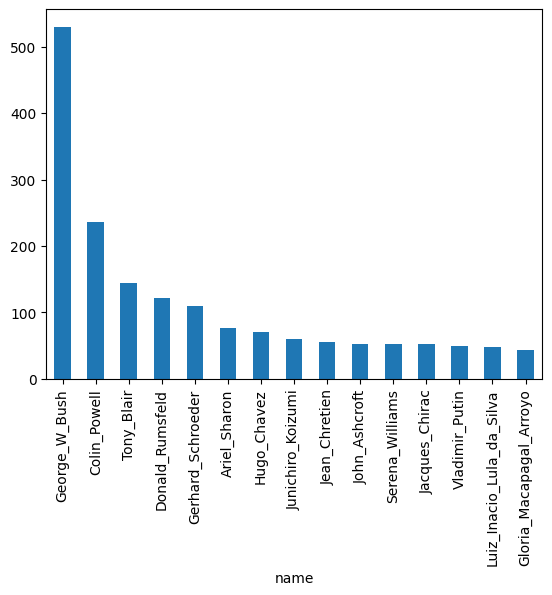

In [60]:
image_paths['name'].value_counts()[:15].plot(kind = "bar")

In [61]:
def directory_mover(data, dir_name):
    destination_root = DATASET_PATH / dir_name
    destination_root.mkdir(parents=True, exist_ok=True)
    count = 0
    for image, person in zip(data["image_path"], data["name"]):
        person_dir = destination_root / person
        person_dir.mkdir(exist_ok=True)
        source = IMAGE_PATH / image
        destination = person_dir / Path(image).name
        shutil.copy(source, destination)
        count += 1
    print(f"Moved {count} images to {dir_name} folder.")

# 8. Create Balanced Dataset

In [62]:
min_val = image_paths.name.value_counts().head(15).min()
multi_data = pd.concat(
    image_paths[image_paths.name == name].sample(min_val)
 for name in image_paths.name.value_counts().head(15).index.tolist())
multi_data

,name,image_path
1871,George_W_Bush,George_W_Bush/George_W_Bush_0340.jpg
1871,George_W_Bush,George_W_Bush/George_W_Bush_0446.jpg
1871,George_W_Bush,George_W_Bush/George_W_Bush_0517.jpg
1871,George_W_Bush,George_W_Bush/George_W_Bush_0191.jpg
1871,George_W_Bush,George_W_Bush/George_W_Bush_0049.jpg
...,...,...
1933,Gloria_Macapagal_Arroyo,Gloria_Macapagal_Arroyo/Gloria_Macapagal_Arroy...
1933,Gloria_Macapagal_Arroyo,Gloria_Macapagal_Arroyo/Gloria_Macapagal_Arroy...
1933,Gloria_Macapagal_Arroyo,Gloria_Macapagal_Arroyo/Gloria_Macapagal_Arroy...
1933,Gloria_Macapagal_Arroyo,Gloria_Macapagal_Arroyo/Gloria_Macapagal_Arroy...


# 9. Train-Test Split

In [63]:
multi_train, multi_test = train_test_split(multi_data, test_size=0.2)
multi_train, multi_val = train_test_split(multi_train,test_size=0.2)

# 10. CNN Model

In [64]:
multi_classifier = tf.keras.Sequential()
multi_classifier.add(tf.keras.Input((250, 250, 3)))
multi_classifier.add(tf.keras.layers.Rescaling(1./255))
multi_classifier.add(tf.keras.layers.RandomFlip("horizontal"))
multi_classifier.add(tf.keras.layers.RandomZoom(0.1))
multi_classifier.add(tf.keras.layers.Conv2D(32, (3, 3), activation="relu"))
multi_classifier.add(tf.keras.layers.Conv2D(32, (3, 3), activation="relu"))
# multi_classifier.add(tf.keras.layers.Conv2D(32, (3, 3), activation="relu"))
multi_classifier.add(tf.keras.layers.MaxPooling2D((2, 2)))
multi_classifier.add(tf.keras.layers.Conv2D(64, (3, 3), activation="relu"))
multi_classifier.add(tf.keras.layers.Conv2D(64, (3, 3), activation="relu"))
# multi_classifier.add(tf.keras.layers.Conv2D(64, (3, 3), activation="relu"))
multi_classifier.add(tf.keras.layers.MaxPooling2D((2, 2)))
multi_classifier.add(tf.keras.layers.Conv2D(128, (3, 3), activation="relu"))
# multi_classifier.add(tf.keras.layers.Conv2D(128, (3, 3), activation="relu"))
multi_classifier.add(tf.keras.layers.MaxPooling2D((2, 2)))
multi_classifier.add(tf.keras.layers.Conv2D(256, (3, 3), activation="relu"))
multi_classifier.add(tf.keras.layers.MaxPooling2D((2, 2)))
multi_classifier.add(tf.keras.layers.Flatten())
multi_classifier.add(tf.keras.layers.Dense(units = 128, activation = 'relu'))
multi_classifier.add(tf.keras.layers.Dropout(0.5))
multi_classifier.add(tf.keras.layers.Dense(units = 15, activation = 'softmax'))
multi_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

# 11. Prepare Directory Structure

In [65]:
WORKING_DIR = Path("/kaggle/working1")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
def directory_mover(data, dir_name):
    destination_root = WORKING_DIR / dir_name
    destination_root.mkdir(parents=True, exist_ok=True)
    count = 0
    for image, person in zip(data["image_path"], data["name"]):
        person_dir = destination_root / person
        person_dir.mkdir(exist_ok=True)
        source = IMAGE_PATH / image
        destination = person_dir / Path(image).name
        shutil.copy(source, destination)
        count += 1
    print(f"Moved {count} images to {dir_name} folder.")

directory_mover(multi_train,"train_multi/")
directory_mover(multi_test,"test_multi/")

Moved 422 images to train_multi/ folder.
Moved 132 images to test_multi/ folder.


# 12. Create TensorFlow Dataset

In [66]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    WORKING_DIR / "train_multi",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(250, 250),
    batch_size=32
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    WORKING_DIR / "train_multi",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(250, 250),
    batch_size=32
)

Found 665 files belonging to 15 classes.
Using 532 files for training.
Found 665 files belonging to 15 classes.
Using 133 files for validation.


In [67]:
print(train_dataset.class_names)
print(len(train_dataset.class_names))

['Ariel_Sharon', 'Colin_Powell', 'Donald_Rumsfeld', 'George_W_Bush', 'Gerhard_Schroeder', 'Gloria_Macapagal_Arroyo', 'Hugo_Chavez', 'Jacques_Chirac', 'Jean_Chretien', 'John_Ashcroft', 'Junichiro_Koizumi', 'Luiz_Inacio_Lula_da_Silva', 'Serena_Williams', 'Tony_Blair', 'Vladimir_Putin']
15


# 13. Train Model

In [71]:
history = multi_classifier.fit(
    train_dataset,
    epochs=60,
    validation_data=val_dataset,
    shuffle=False,
)

Epoch 1/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - loss: 0.1184 - sparse_categorical_accuracy: 0.9530 - val_loss: 0.7757 - val_sparse_categorical_accuracy: 0.8421
Epoch 2/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - loss: 0.1032 - sparse_categorical_accuracy: 0.9643 - val_loss: 1.0026 - val_sparse_categorical_accuracy: 0.8647
Epoch 3/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - loss: 0.1553 - sparse_categorical_accuracy: 0.9455 - val_loss: 0.8066 - val_sparse_categorical_accuracy: 0.8120
Epoch 4/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - loss: 0.1525 - sparse_categorical_accuracy: 0.9398 - val_loss: 0.8470 - val_sparse_categorical_accuracy: 0.8421
Epoch 5/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - loss: 0.1486 - sparse_categorical_accuracy: 0.9361 - val_loss: 0.7413 - val_sparse_categorical_accuracy: 0.8120
Epoch 6/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - loss: 0.1965 - sparse_categorical_accuracy: 0.9305 - val_loss: 1.0932 - val_sparse_categorical_accuracy: 0.8045
Epoc

# 14. Plot Accuracy & Loss

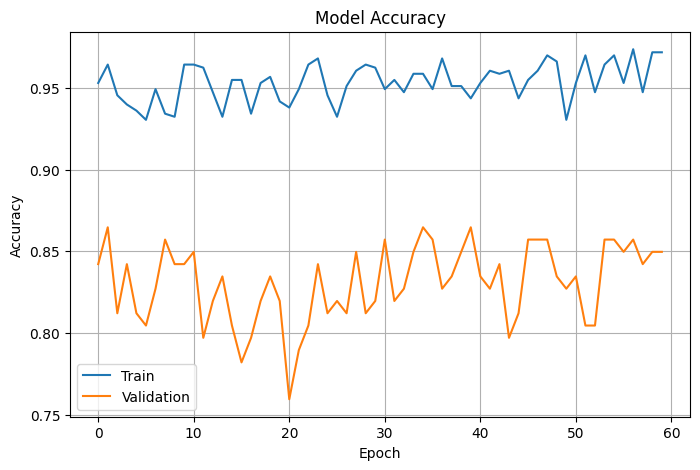

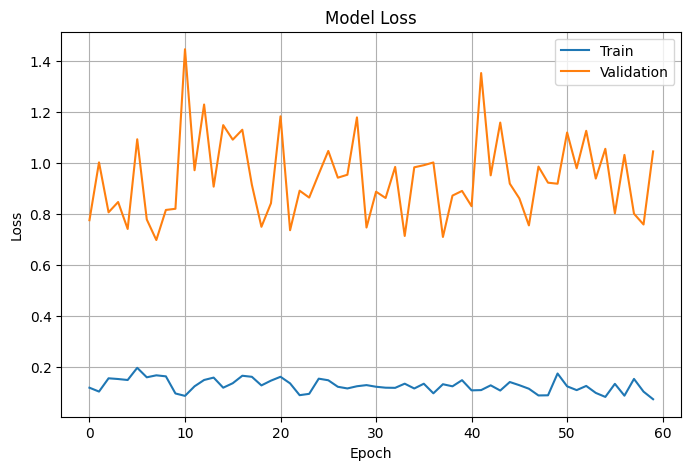

In [75]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['sparse_categorical_accuracy'], label='Train')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()